# Real-Time Pen and Pencil Detection

A lightweight object detection project using YOLOv8n to detect pens and pencils as a single class.

The workflow includes dataset inspection, model fine-tuning, validation, and live webcam detection with OpenCV. The webcam application displays bounding boxes, confidence scores, and measured FPS.

## Project Structure

1. Environment setup
2. Dataset inspection and preparation
3. Model training
4. Model evaluation
5. Model export
6. Live webcam testing

## 1. Environment Setup

Install the dependencies and check the available training hardware.

In [4]:
%pip install -q ultralytics opencv-python pyyaml

In [5]:
from pathlib import Path
import zipfile

import cv2
import torch
import ultralytics
import yaml

from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print(f"Ultralytics version: {ultralytics.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Training device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Ultralytics version: 8.4.174
OpenCV version: 4.14.0
PyTorch version: 2.11.0+cu130
Training device: 0
GPU: Tesla T4


## 2. Dataset Inspection

The project uses a public, labeled pen and pencil dataset.

Before training, the dataset configuration, class names, annotations, and split sizes are inspected.

### 2.1 Dataset Extraction

Extract the uploaded ZIP file and locate the dataset configuration.

In [6]:
UPLOAD_DIR = Path("/content")
EXTRACT_DIR = UPLOAD_DIR / "pen_dataset"

zip_files = sorted(UPLOAD_DIR.glob("*.zip"))

if not zip_files:
    raise FileNotFoundError(
        "No ZIP file found in /content. Upload the dataset ZIP first."
    )

if len(zip_files) > 1:
    raise ValueError(
        "Multiple ZIP files found: "
        f"{[path.name for path in zip_files]}. "
        "Keep only the dataset ZIP in /content."
    )

ZIP_PATH = zip_files[0]
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as archive:
    archive.extractall(EXTRACT_DIR)

yaml_files = sorted(EXTRACT_DIR.rglob("data.yaml"))

if len(yaml_files) != 1:
    raise ValueError(
        f"Expected one data.yaml file, found {len(yaml_files)}."
    )

ORIGINAL_YAML = yaml_files[0]
DATASET_ROOT = ORIGINAL_YAML.parent

print(f"Dataset archive: {ZIP_PATH.name}")
print(f"Dataset directory: {DATASET_ROOT}")
print(f"Configuration file: {ORIGINAL_YAML}")

Dataset archive: PEN.v2i.yolov8.zip
Dataset directory: /content/pen_dataset
Configuration file: /content/pen_dataset/data.yaml


### 2.2 Dataset Configuration

Inspect the original class names and split paths before making any changes.

In [7]:
with ORIGINAL_YAML.open("r") as file:
    original_config = yaml.safe_load(file)

print(yaml.safe_dump(original_config, sort_keys=False))

train: ../train/images
val: ../valid/images
test: ../test/images
nc: 1
names:
- PEN
roboflow:
  workspace: sown
  project: pen-pfrzk
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/sown/pen-pfrzk/dataset/2



### 2.3 Image and Annotation Counts

Count the images in each split and check for matching annotation files.

Images with non-empty annotations are counted separately from images without object labels.

In [8]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

split_folders = {}

split_names = {
    "train": ("train",),
    "val": ("valid", "val"),
    "test": ("test",),
}

for split, folder_names in split_names.items():
    for folder_name in folder_names:
        image_dir = DATASET_ROOT / folder_name / "images"
        label_dir = DATASET_ROOT / folder_name / "labels"

        if image_dir.is_dir():
            split_folders[split] = (image_dir, label_dir)
            break

if "train" not in split_folders or "val" not in split_folders:
    image_folders = [
        str(path) for path in EXTRACT_DIR.rglob("images")
        if path.is_dir()
    ]

    raise ValueError(
        "The expected train/validation folders were not found. "
        f"Available image folders: {image_folders}"
    )

dataset_summary = []

for split, (image_dir, label_dir) in split_folders.items():
    images = sorted(
        path for path in image_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    )

    labeled_images = 0
    empty_labels = 0
    missing_labels = []

    for image_path in images:
        label_path = label_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            missing_labels.append(image_path.name)
        elif label_path.read_text().strip():
            labeled_images += 1
        else:
            empty_labels += 1

    dataset_summary.append({
        "split": split,
        "images": len(images),
        "labeled_images": labeled_images,
        "empty_labels": empty_labels,
        "missing_labels": len(missing_labels),
    })

    if missing_labels:
        print(f"{split}: examples of missing labels: {missing_labels[:5]}")

    if not images:
        raise ValueError(f"The {split} split contains no images.")

header = (
    f"{'Split':<10}"
    f"{'Images':>10}"
    f"{'Labeled':>12}"
    f"{'Empty':>10}"
    f"{'Missing':>10}"
)

print(header)
print("-" * len(header))

for row in dataset_summary:
    print(
        f"{row['split']:<10}"
        f"{row['images']:>10}"
        f"{row['labeled_images']:>12}"
        f"{row['empty_labels']:>10}"
        f"{row['missing_labels']:>10}"
    )

total_images = sum(row["images"] for row in dataset_summary)
total_labeled = sum(row["labeled_images"] for row in dataset_summary)

print(f"\nTotal images: {total_images}")
print(f"Images with object annotations: {total_labeled}")

if total_labeled < 100:
    raise ValueError(
        "At least 100 images with pen/pencil annotations are needed."
    )

Split         Images     Labeled     Empty   Missing
----------------------------------------------------
train            894         867        27         0
val               85          85         0         0
test              43          40         3         0

Total images: 1022
Images with object annotations: 992


### 2.4 Dataset Summary

The dataset contains one class: `PEN`.

| Split | Images | Images with object annotations | Empty annotations |
|-------|-------:|-------------------------------:|------------------:|
| Training | 894 | 867 | 27 |
| Validation | 85 | 85 | 0 |
| Test | 43 | 40 | 3 |
| Total | 1,022 | 992 | 30 |

All images have matching annotation files.

Source: [Roboflow Universe — PEN, version 2](https://universe.roboflow.com/sown/pen-pfrzk/dataset/2)  
License: CC BY 4.0

### 2.5 Annotation Validation

Check that each annotation contains a valid class ID and normalized bounding box coordinates.

In [9]:
import math

annotation_errors = []
object_count = 0

for split, (image_dir, label_dir) in split_folders.items():
    for label_path in sorted(label_dir.glob("*.txt")):
        for line_number, line in enumerate(
            label_path.read_text().splitlines(), start=1
        ):
            if not line.strip():
                continue

            values = line.split()

            try:
                if len(values) != 5:
                    raise ValueError("Expected 5 values per bounding box.")

                class_id, x, y, width, height = map(float, values)

                if not all(
                    math.isfinite(value)
                    for value in (class_id, x, y, width, height)
                ):
                    raise ValueError("Non-finite value found.")

                if class_id != 0:
                    raise ValueError(f"Unexpected class ID: {class_id}")

                if not (0 <= x <= 1 and 0 <= y <= 1):
                    raise ValueError("Box center is outside the valid range.")

                if not (0 < width <= 1 and 0 < height <= 1):
                    raise ValueError("Invalid box width or height.")

                object_count += 1

            except ValueError as error:
                annotation_errors.append(
                    f"{label_path.name}, line {line_number}: {error}"
                )

print("Bounding boxes checked:", object_count)
print("Annotation errors:", len(annotation_errors))

if annotation_errors:
    for error in annotation_errors[:10]:
        print(error)

    raise ValueError("Fix the annotation errors before training.")

Bounding boxes checked: 2018
Annotation errors: 0


### 2.6 Visual Inspection

Display sample images with their annotated bounding boxes to inspect object coverage and labeling quality.

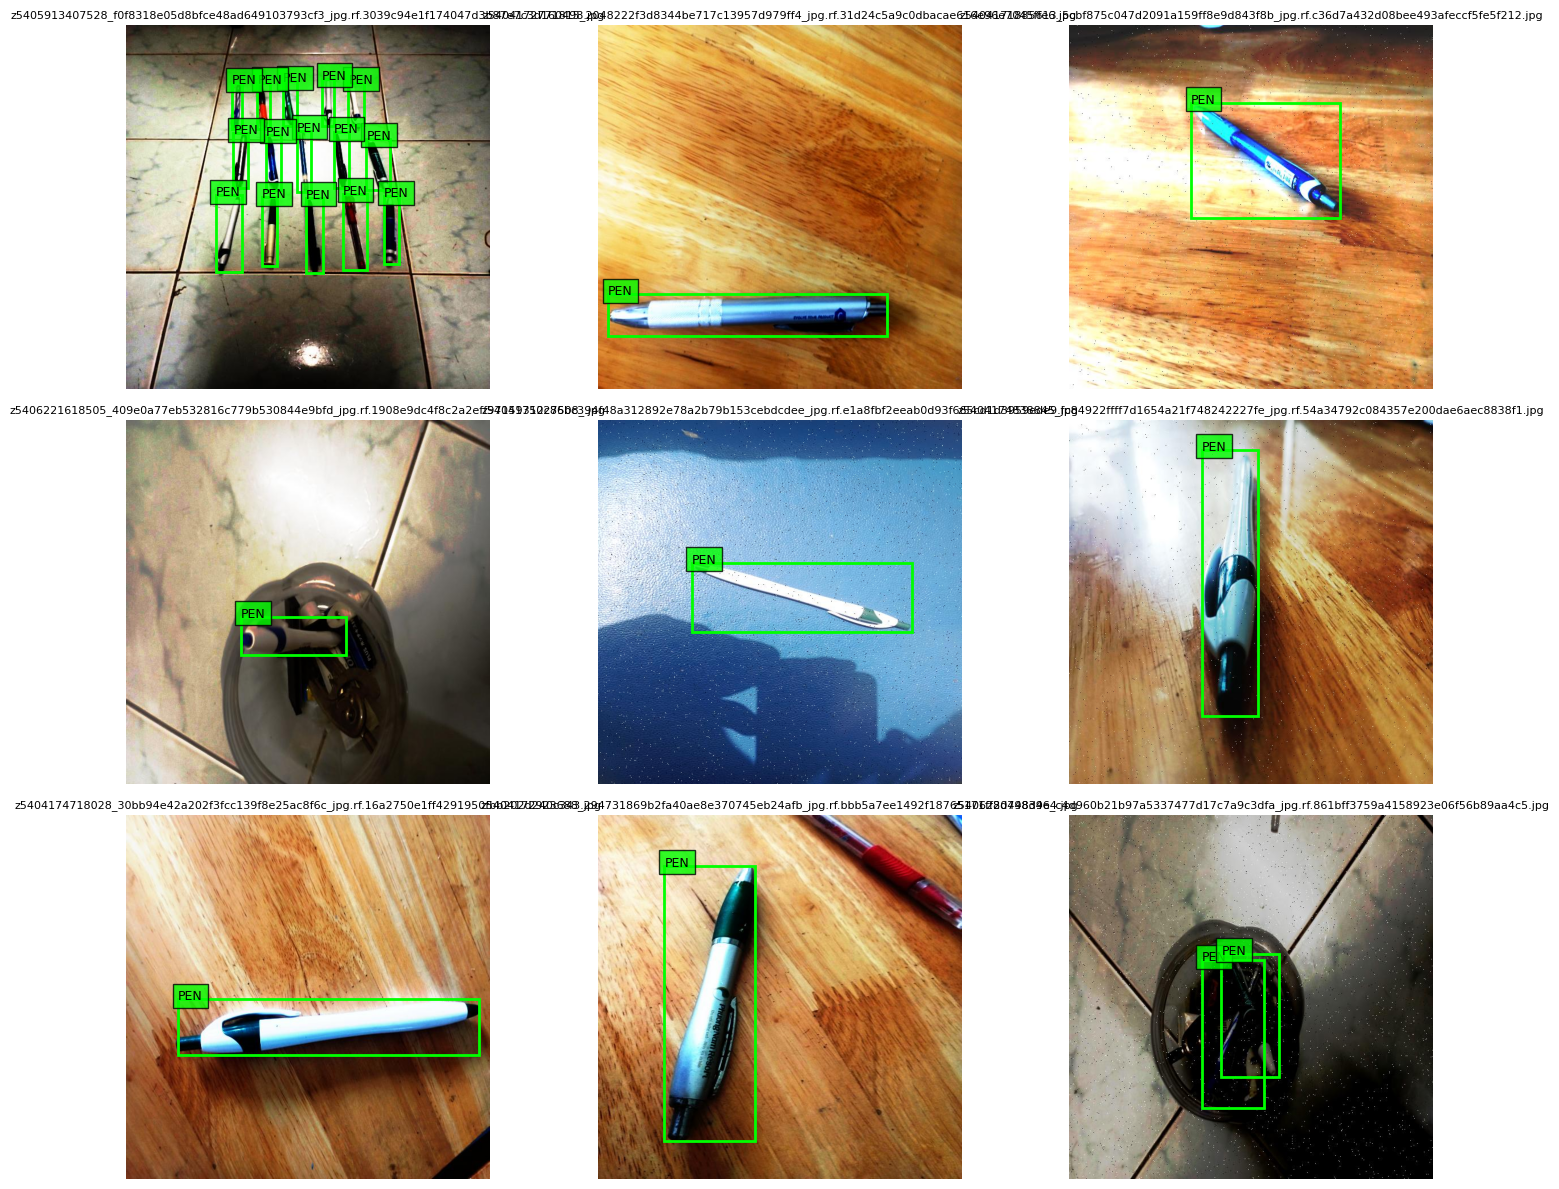

In [10]:
import random
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Rectangle

random_generator = random.Random(42)

train_image_dir, train_label_dir = split_folders["train"]

labeled_train_images = [
    path
    for path in sorted(train_image_dir.iterdir())
    if path.suffix.lower() in IMAGE_EXTENSIONS
    and (train_label_dir / f"{path.stem}.txt").exists()
    and (train_label_dir / f"{path.stem}.txt").read_text().strip()
]

sample_images = random_generator.sample(
    labeled_train_images,
    k=min(9, len(labeled_train_images)),
)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax in axes.flat:
    ax.axis("off")

for ax, image_path in zip(axes.flat, sample_images):
    image = Image.open(image_path).convert("RGB")
    image_width, image_height = image.size

    ax.imshow(image)
    ax.set_title(image_path.name, fontsize=8)

    label_path = train_label_dir / f"{image_path.stem}.txt"

    for line in label_path.read_text().splitlines():
        if not line.strip():
            continue

        class_id, x, y, width, height = map(float, line.split())

        box_width = width * image_width
        box_height = height * image_height
        left = x * image_width - box_width / 2
        top = y * image_height - box_height / 2

        ax.add_patch(
            Rectangle(
                (left, top),
                box_width,
                box_height,
                linewidth=2,
                edgecolor="lime",
                facecolor="none",
            )
        )

        ax.text(
            left,
            max(0, top),
            "PEN",
            color="black",
            fontsize=9,
            bbox={"facecolor": "lime", "alpha": 0.8},
        )

plt.tight_layout()
plt.show()

### 2.7 Background Image Inspection

Inspect images with empty annotation files to check whether they are valid background examples.

Images with empty annotations: 30


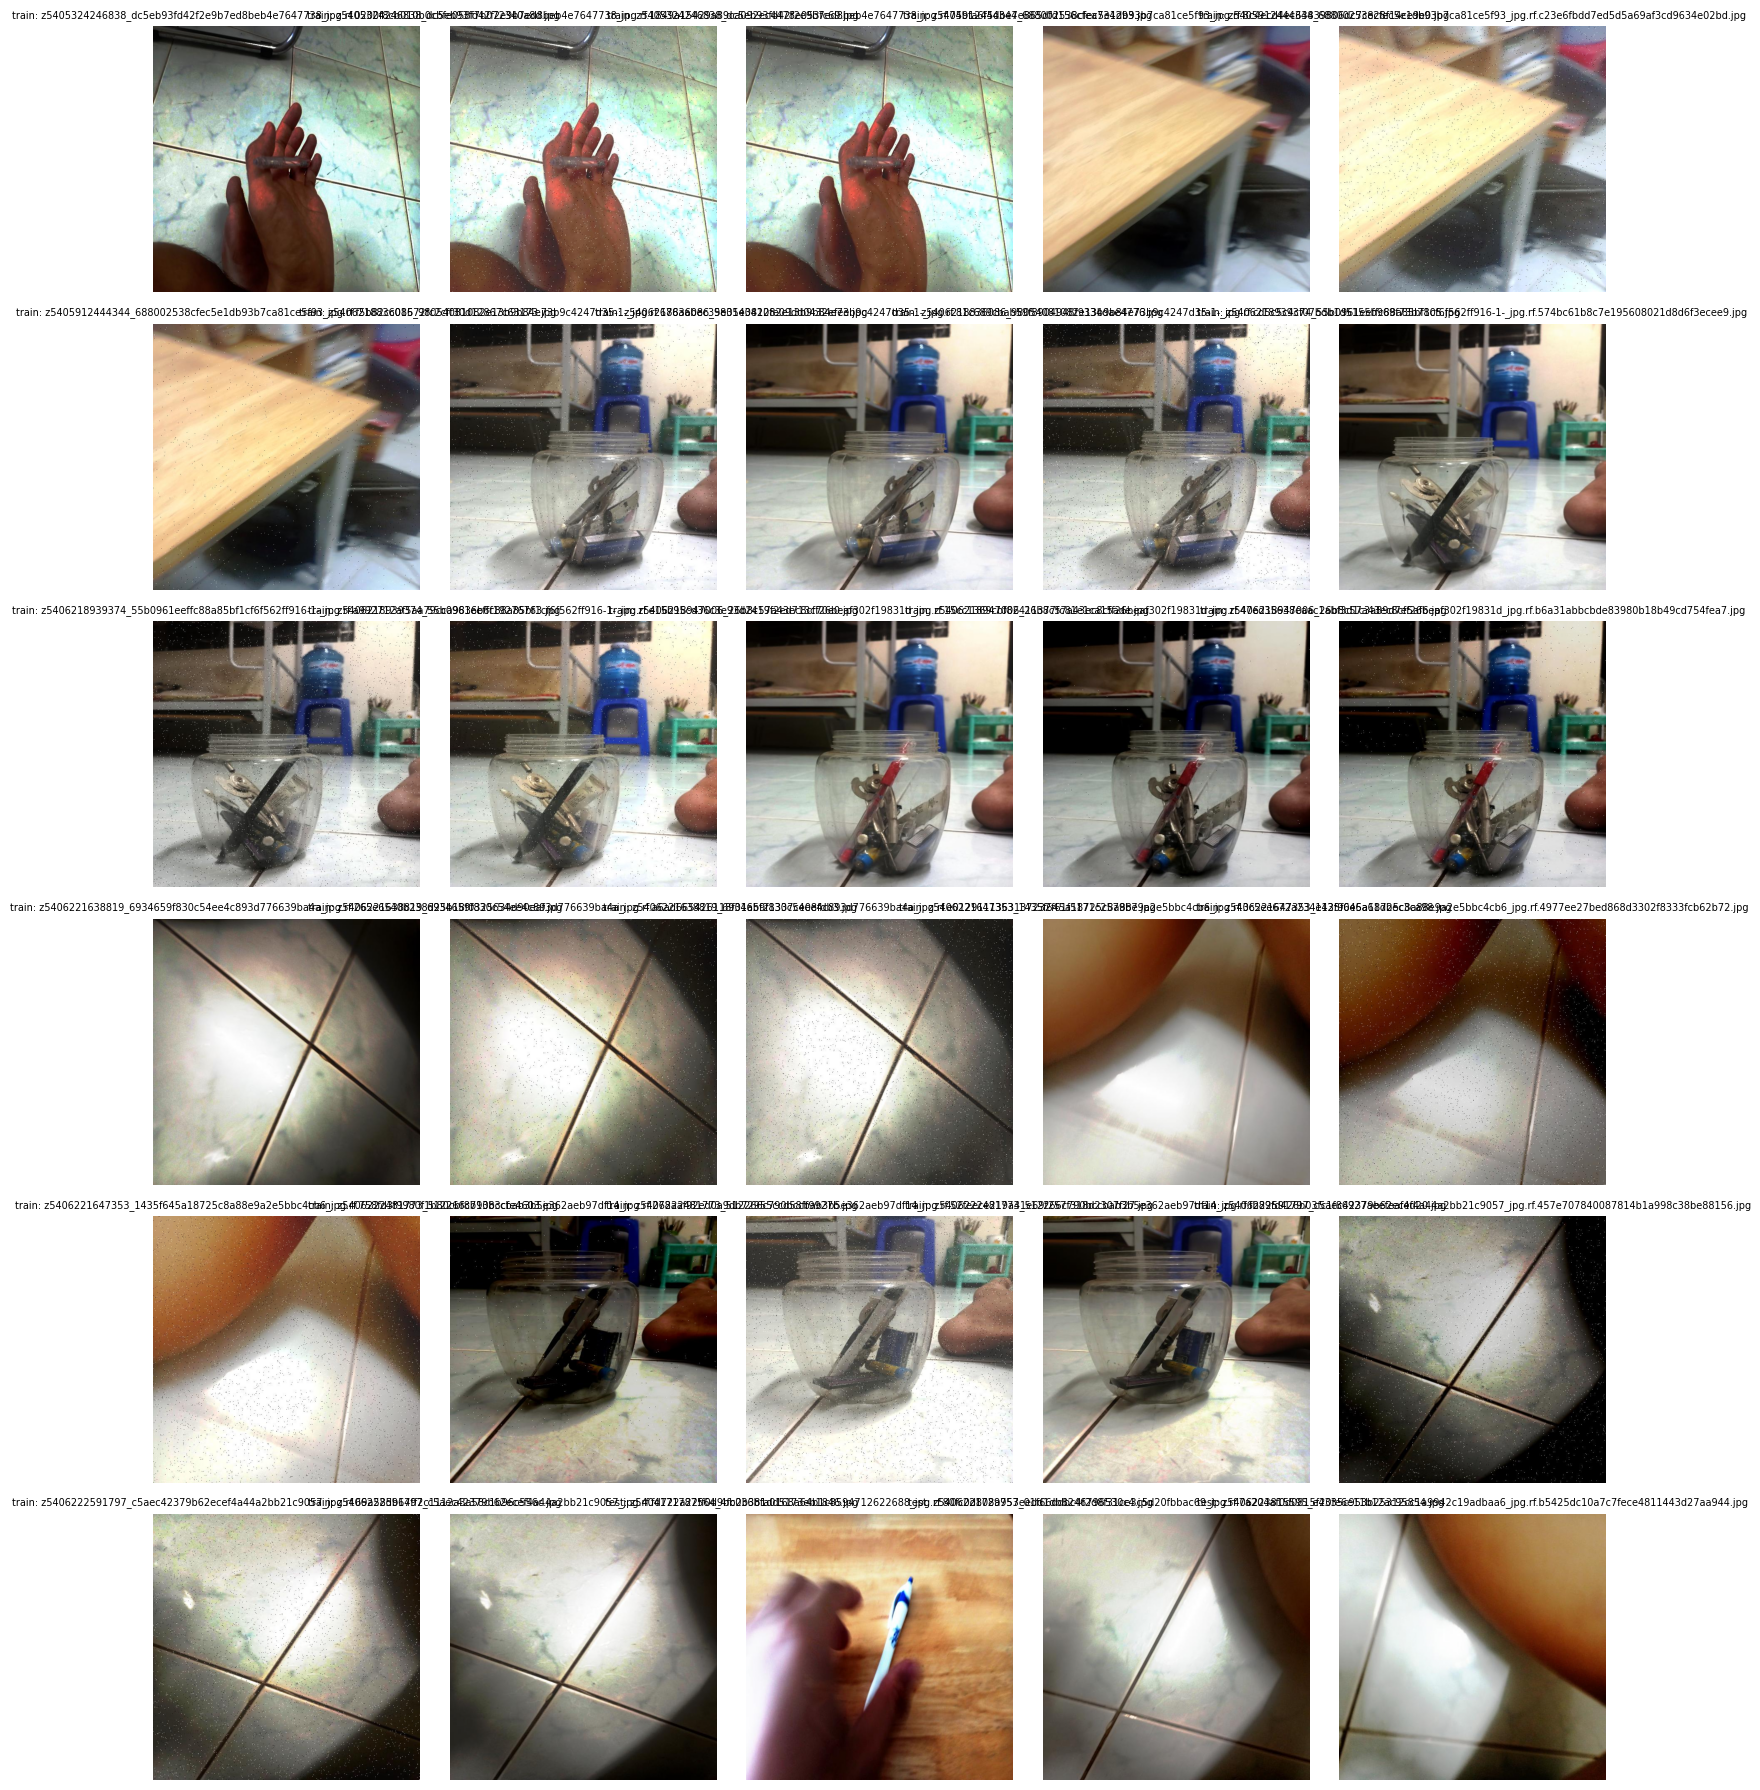

In [11]:
empty_annotation_images = []

for split, (image_dir, label_dir) in split_folders.items():
    for image_path in sorted(image_dir.iterdir()):
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        label_path = label_dir / f"{image_path.stem}.txt"

        if label_path.exists() and not label_path.read_text().strip():
            empty_annotation_images.append((split, image_path))

print("Images with empty annotations:", len(empty_annotation_images))

if empty_annotation_images:
    columns = 5
    rows = math.ceil(len(empty_annotation_images) / columns)

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(15, rows * 3),
        squeeze=False,
    )

    for ax in axes.flat:
        ax.axis("off")

    for ax, (split, image_path) in zip(
        axes.flat, empty_annotation_images
    ):
        ax.imshow(Image.open(image_path).convert("RGB"))
        ax.set_title(f"{split}: {image_path.name}", fontsize=7)

    plt.tight_layout()
    plt.show()

### 2.8 Annotation Quality Review

Visual inspection revealed objects in some images with empty annotations. These images are excluded from the working dataset.

Some labeled images also contain unannotated pens. This remains a dataset limitation and may affect detection performance.

The original dataset is preserved without modification.

In [12]:
import shutil

CLEAN_ROOT = Path("/content/pen_dataset_clean")
CLEAN_YAML = CLEAN_ROOT / "data.yaml"

if CLEAN_ROOT.exists():
    shutil.rmtree(CLEAN_ROOT)

clean_summary = []

for split, (image_dir, label_dir) in split_folders.items():
    output_images = CLEAN_ROOT / split / "images"
    output_labels = CLEAN_ROOT / split / "labels"

    output_images.mkdir(parents=True, exist_ok=True)
    output_labels.mkdir(parents=True, exist_ok=True)

    kept = 0
    excluded = 0

    for image_path in sorted(image_dir.iterdir()):
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        label_path = label_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            raise FileNotFoundError(f"Missing annotation: {label_path}")

        if not label_path.read_text().strip():
            excluded += 1
            continue

        shutil.copy2(image_path, output_images / image_path.name)
        shutil.copy2(label_path, output_labels / label_path.name)
        kept += 1

    clean_summary.append({
        "split": split,
        "kept": kept,
        "excluded": excluded,
    })

clean_config = {
    "path": str(CLEAN_ROOT),
    "train": "train/images",
    "val": "val/images",
    "nc": 1,
    "names": ["PEN"],
}

if "test" in split_folders:
    clean_config["test"] = "test/images"

with CLEAN_YAML.open("w") as file:
    yaml.safe_dump(clean_config, file, sort_keys=False)

print(f"{'Split':<10}{'Kept':>10}{'Excluded':>12}")
print("-" * 32)

for row in clean_summary:
    print(
        f"{row['split']:<10}"
        f"{row['kept']:>10}"
        f"{row['excluded']:>12}"
    )

print("\nTraining configuration:")
print(CLEAN_YAML.read_text())

Split           Kept    Excluded
--------------------------------
train            867          27
val               85           0
test              40           3

Training configuration:
path: /content/pen_dataset_clean
train: train/images
val: val/images
nc: 1
names:
- PEN
test: test/images



### Working Dataset

| Split | Images |
|-------|-------:|
| Training | 867 |
| Validation | 85 |
| Test | 40 |
| Total | 992 |

Thirty images with empty annotations were excluded after visual inspection. The original split assignments were retained.

This filtering does not resolve incomplete annotations in the remaining images. Background-only performance will also need to be checked during live testing.

## 3. Model Training

YOLOv8n is fine-tuned on the single-class PEN dataset.

The nano model is selected as a lightweight starting point for webcam inference. Its actual speed and detection quality will be measured during live testing.

Training uses the training split, while the validation split is used to monitor performance. The test split is reserved for final evaluation.

In [13]:
TRAINING_CONFIG = {
    "data": str(CLEAN_YAML),
    "epochs": 50,
    "imgsz": 640,
    "batch": 8,
    "patience": 10,
    "device": DEVICE,
    "workers": 2,
    "seed": 42,
    "project": "/content/runs/detect",
    "name": "pen_yolov8n",
    "exist_ok": False,
    "plots": True,
    "save": True,
}

print(yaml.safe_dump(TRAINING_CONFIG, sort_keys=False))

data: /content/pen_dataset_clean/data.yaml
epochs: 50
imgsz: 640
batch: 8
patience: 10
device: 0
workers: 2
seed: 42
project: /content/runs/detect
name: pen_yolov8n
exist_ok: false
plots: true
save: true



In [14]:
model = YOLO("yolov8n.pt")

train_results = model.train(**TRAINING_CONFIG)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pen_dataset_clean/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pen_yolov8n, nbs=64, nms=None, opset=None, optimize=F

### 3.1 Training Outputs

Locate the training results and confirm that the best model checkpoint was saved.

In [17]:
RUN_DIR = Path(model.trainer.save_dir)
BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"
LAST_WEIGHTS = RUN_DIR / "weights" / "last.pt"

if not BEST_WEIGHTS.is_file():
    raise FileNotFoundError("The best model checkpoint was not found.")

print("Training directory:", RUN_DIR)
print("Best checkpoint:", BEST_WEIGHTS)
print("Last checkpoint:", LAST_WEIGHTS)
print(f"Best checkpoint size: {BEST_WEIGHTS.stat().st_size / 1024**2:.2f} MB")

Training directory: /content/runs/detect/pen_yolov8n
Best checkpoint: /content/runs/detect/pen_yolov8n/weights/best.pt
Last checkpoint: /content/runs/detect/pen_yolov8n/weights/last.pt
Best checkpoint size: 5.96 MB


## 4. Model Evaluation

Training completed after 50 epochs on a Tesla T4 GPU.

The best checkpoint was evaluated on 85 validation images containing 169 annotated objects.

### Validation Results

| Metric | Value |
|--------|------:|
| Precision | 0.975 |
| Recall | 0.914 |
| mAP@50 | 0.979 |
| mAP@50–95 | 0.778 |

These results describe performance on the validation split, not live webcam performance.

Incomplete annotations and limited scene variety may affect how well these results represent real-world detection quality.

### 4.1 Training Curves

Training losses and validation metrics are plotted across epochs.

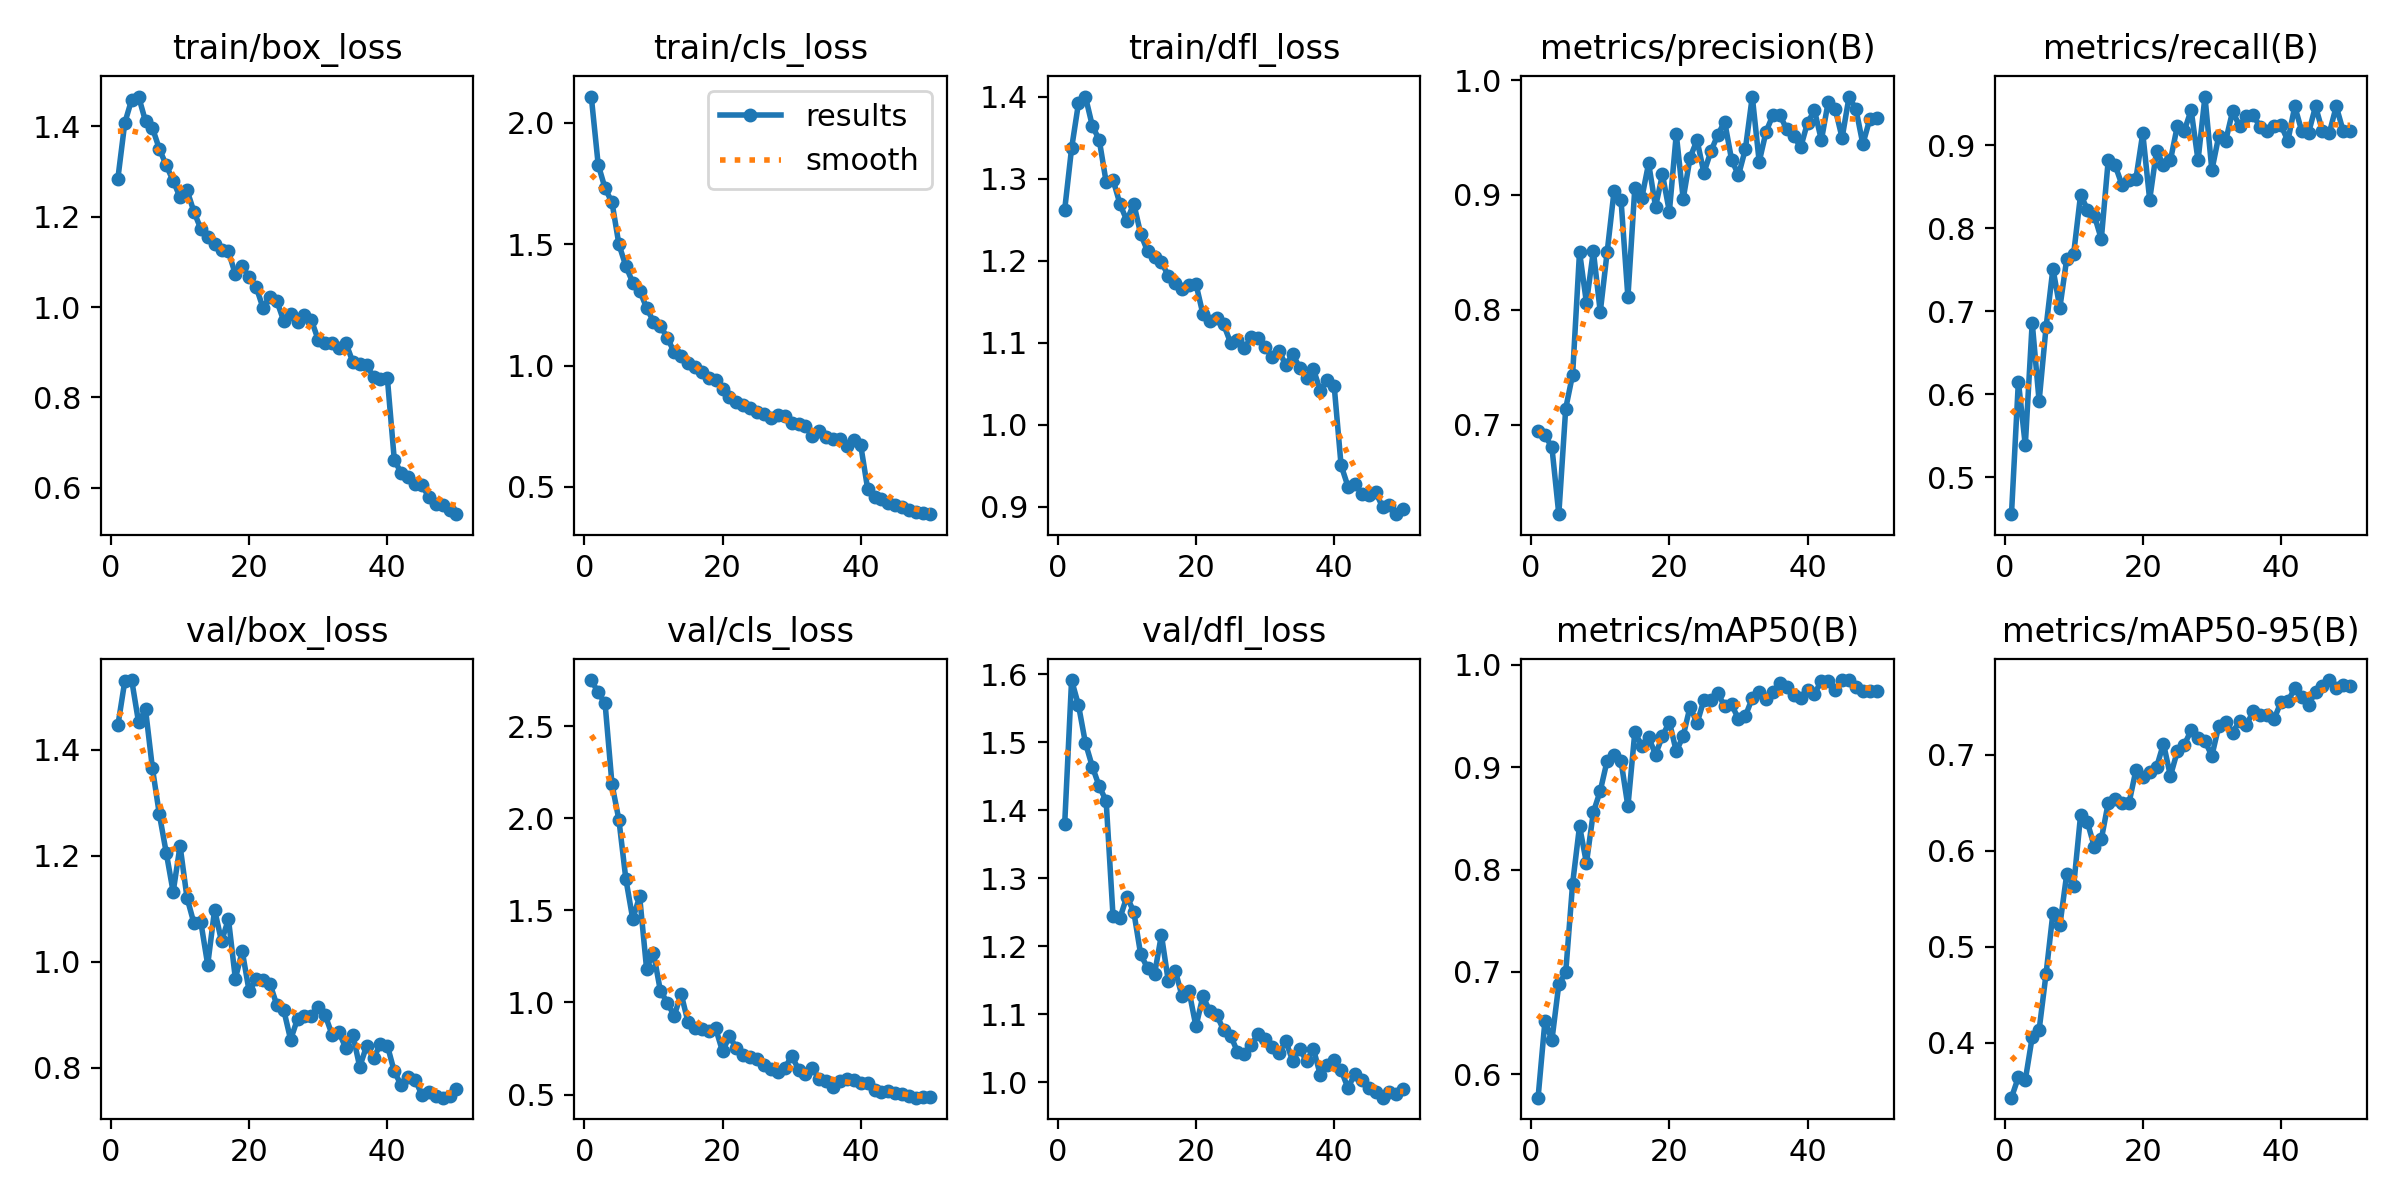

In [19]:
from IPython.display import display, Image as DisplayImage

training_plot = RUN_DIR / "results.png"

if training_plot.is_file():
    display(DisplayImage(filename=str(training_plot)))
else:
    print("Training plot not found:", training_plot)

### Training Observations

Training and validation losses generally decreased throughout training. Precision, recall, and mAP improved and became more stable toward the final epochs.

The curves do not show a clear, sustained increase in validation loss. However, dataset similarity and incomplete annotations limit the conclusions that can be drawn about performance in new environments.

### 4.2 Test Set Evaluation

The best checkpoint is evaluated on the held-out test split.

The test split was not used for model training or checkpoint selection.

In [20]:
best_model = YOLO(str(BEST_WEIGHTS))

test_metrics = best_model.val(
    data=str(CLEAN_YAML),
    split="test",
    imgsz=640,
    batch=8,
    device=DEVICE,
    workers=2,
    plots=True,
    project="/content/runs/evaluate",
    name="pen_test",
    exist_ok=False,
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1549.4±400.0 MB/s, size: 42.8 KB)
val: Scanning /content/pen_dataset_clean/test/labels... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 1.9Kit/s 0.0s
val: New cache created: /content/pen_dataset_clean/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.2it/s 1.6s
                   all         40         67      0.951       0.91       0.97      0.696
Speed: 6.1ms preprocess, 8.4ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/evaluate/pen_test


In [21]:
test_scores = {
    "Precision": float(test_metrics.box.mp),
    "Recall": float(test_metrics.box.mr),
    "mAP@50": float(test_metrics.box.map50),
    "mAP@50-95": float(test_metrics.box.map),
}

print("Test results")
print("-" * 30)

for metric_name, value in test_scores.items():
    print(f"{metric_name:<15} {value:.4f}")

Test results
------------------------------
Precision       0.9508
Recall          0.9104
mAP@50          0.9695
mAP@50-95       0.6962


### Test Results

The best checkpoint was evaluated on 40 test images.

| Metric | Validation | Test |
|--------|-----------:|-----:|
| Precision | 0.975 | 0.9508 |
| Recall | 0.914 | 0.9104 |
| mAP@50 | 0.979 | 0.9695 |
| mAP@50–95 | 0.778 | 0.6962 |

Test performance is slightly lower than validation performance, with the largest difference in mAP@50–95.

These results describe performance on the labeled dataset. Live webcam performance is evaluated separately.

### Evaluation Limitations

- Visual inspection identified incomplete annotations in some images.
- Several inspected images show similar scenes and objects.
- Images with empty annotations were excluded after some were found to contain pens.
- The cleaned test split contains only 40 images and no background-only examples.
- Pencil detection has not yet been verified.
- Performance under new lighting, backgrounds, and camera angles must be tested with the live webcam application.

## 5. Save the Model

The fine-tuned `best.pt` checkpoint is saved for local webcam inference.

The original pretrained weights are not used for the final webcam application.

In [22]:
from google.colab import files

if not BEST_WEIGHTS.is_file():
    raise FileNotFoundError("The trained checkpoint was not found.")

files.download(str(BEST_WEIGHTS))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Live Webcam Test

The following FPS entries were present in the supplied notebook, but the raw live-test logs or video were not provided. Treat them as unverified reported values and replace them with measurements from your own computer before submission.

| Condition | Reported FPS (unverified) | Detection |
|---|---:|---|
| Normal light, plain background | 15.6 | Pen detected |
| Low light | 15.2 | Pen detected |
| Cluttered background | 14.8 | Pen detected |
